# Projet de Statistique Appliquée

## Étude comparative de l'efficacité des hôpitaux selon leur statut

Projet d'économétrie appliqué s'appuyant sur les données publiques de la Statistique Annuelle des Établissements (SAE) et d'Hospidiag.

### 1 - Importation des bibliothèques

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.iv import IV2SLS

### 2 - Importations des données

Extraction des Outputs et Inputs de 2022, dans un premiers temps on s'intéresse aux services d'Urgence, de Médecine, Chirurgie et obstétrique (MCO), Soins de suite et rééducation (SSR), Psychiatrie, Unité de soins de longue durée (USLD), et séances (séances de dyalise, de chimiothérapie, etc).

In [3]:
SYGEN2022 = pd.read_csv("SAE/2022/SYGEN_2022r.csv", sep=";", encoding="latin-1")
Data = SYGEN2022[['FI','FI_EJ','EFFSAL_TOT','EFFLIB_TOT','EFF_INFSANSSPE','EFF_INFAVECSPE','EFF_AID','EFF_DIR','EFF_DIRSOI','EFF_AUTADM','SEJHC_SSR','SEJHC_MCO','SEJHP_MCO','SEJ_HTP_TOT','VEN_HDJ_TOT','VEN_HDN_TOT','SEAN_HEMO_CENTRE','SEAN_CHIMIO','SEAN_RADIO']]

On extrait le statut des différents établissement depuis le fichier FINESS.xlsx obtenu sur le site SAE diffusion.
On crée une distinction entre les hôpitaux publics classiques qui serviront par la suite de référence et les grands hôpitaux publics, les CHU, en ajoutant une catégorie 'CHU' dans la colonne 'Statut'

In [4]:
FINESS = pd.read_excel("finess.xlsx")
FINESS = FINESS.rename(columns={"FINESS":"FI","Statut Juridique":"Statut"})

CHU = pd.read_excel("CHRU.xlsx")
CHU["FINESS"] = CHU["FINESS"].astype(object)

FINESS.loc[FINESS['Raison sociale'].isin(CHU['Raison sociale']), "Statut"] = "CHU"  #Ajout du statut CHU dans la colonne Statut de FINESS
FINESS = FINESS.drop(FINESS.columns[[1,2,4]],axis=1)  #supression des colonnes inutiles

Data = Data.merge(FINESS, on="FI", how="left")

In [5]:
print(Data.shape)
print(SYGEN2022.shape)

(3988, 20)
(3988, 208)


Extraction des données Hospidiag 2022 :

In [6]:
hd2022 = pd.read_csv("Hospidiag/hd2022.csv", sep=";", decimal = ",", encoding="utf-8")

Ajout des output des services d'urgences (nombre de passages) :

In [7]:
Urg2022 = pd.read_csv("SAE/2022/URGENCES2_2022r.csv", sep=";", encoding="latin-1")
Urg2022 = Urg2022[['FI','PASSU']]
Urg2022 = Urg2022.groupby("FI").sum().reset_index()  # Agrégation des données d'urgences par établissement
Data = Data.merge(Urg2022, on="FI", how="left")

Ajout des entrées au unités de soins longue durée (USLD) :

In [8]:
USLD2022 = pd.read_csv("SAE/2022/USLD_2022r.csv", sep=";", encoding="latin-1")
USLD2022 = USLD2022[['FI','ENT']]
Data = Data.merge(USLD2022, on="FI", how="left")

### 3 - Constructions des variables de la régression

#### 3.1 - Intputs

Total médecins (libéraux et saliariés confondus) : 

In [9]:
Data['EFF_MED'] = Data['EFFSAL_TOT'] + Data['EFFLIB_TOT'].fillna(0)
Data['EFF_MED'].describe()

count    3332.000000
mean       48.876351
std       102.023147
min         0.000000
25%         4.000000
50%        10.000000
75%        48.000000
max      1515.000000
Name: EFF_MED, dtype: float64

Total infirmiers (spécialisés et non-spécialisés) : 

In [10]:
Data['EFF_IDE'] = Data['EFF_INFSANSSPE'] + Data['EFF_INFAVECSPE'].fillna(0)
Data['EFF_IDE'].describe()

count    3530.000000
mean       97.522946
std       204.341642
min         0.000000
25%        11.000000
50%        24.000000
75%        75.000000
max      2090.000000
Name: EFF_IDE, dtype: float64

Total personnel administratif :

In [11]:
Data['EFF_ADMIN'] = Data['EFF_AUTADM'] + Data['EFF_DIRSOI'].fillna(0) + Data['EFF_DIR'].fillna(0)
Data["EFF_ADMIN"].describe()

count    3389.000000
mean       46.102980
std        88.991979
min         0.000000
25%         7.000000
50%        14.000000
75%        40.000000
max       952.000000
Name: EFF_ADMIN, dtype: float64

In [12]:
Data['EFF_DIR'].describe()

count    2616.000000
mean        3.435015
std         3.889435
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        64.000000
Name: EFF_DIR, dtype: float64

NB : la colonne 'EFF_DIRSOI' comptabilisant les effectifs de directeurs de soins par établissements n'a que 1050 lignes renseignées, sa prise en compte fait passer l'effectif moyen en personnel administratif de 62 à 63, l'influence de cette catégorie de personnel peut donc sans doute être considéré comme mineur.

#### 3.2 - Outputs

Total séjours MCO (hospitalisation partielle et complète confondu) :

In [13]:
Data['MCO'] = Data['SEJHP_MCO'] + Data['SEJHC_MCO']
Data['MCO'] = Data['MCO'].fillna(0)
Data['I_MCO'] = (Data['MCO'] > 0).astype(int)

Total séjours en psychiatrie (hospitalisations complètes, venues de jour et venues de nuit) :

In [14]:
Data['PSY'] = Data['SEJ_HTP_TOT'] + Data['VEN_HDJ_TOT'].fillna(0) + Data['VEN_HDN_TOT'].fillna(0)
Data['PSY'].describe()

count      512.000000
mean      7518.765625
std       7778.889299
min          0.000000
25%       1740.250000
50%       5311.000000
75%      10591.750000
max      47168.000000
Name: PSY, dtype: float64

In [15]:
Data['PSY'] = Data['PSY'].fillna(0)
Data['I_PSY'] = (Data['PSY'] > 0).astype(int)

In [16]:
Data["SEANCES"] = Data['SEAN_HEMO_CENTRE'].fillna(0) + Data['SEAN_CHIMIO'] + Data['SEAN_RADIO'].fillna(0)
Data["SEANCES"].describe()

count      728.000000
mean     10178.453297
std      15332.803292
min          0.000000
25%        573.000000
50%       3123.500000
75%      13299.250000
max      81352.000000
Name: SEANCES, dtype: float64

In [17]:
Data['SEANCES'] = Data['SEANCES'].fillna(0)
Data['I_SEANCES'] = (Data['SEANCES'] > 0).astype(int)

In [18]:
Data['PASSU'].describe()

count       623.000000
mean      34725.581059
std       24722.086305
min         314.000000
25%       16610.000000
50%       26651.000000
75%       46619.000000
max      132443.000000
Name: PASSU, dtype: float64

In [19]:
Data['PASSU'] = Data['PASSU'].fillna(0)
Data['I_URG'] = (Data['PASSU'] > 0).astype(int)

In [20]:
Data['PASSU'][Data['PASSU'] > 0]

0       42384.0
1       16727.0
13      22583.0
23      23369.0
24      38727.0
         ...   
3922    49067.0
3923    66717.0
3924    50064.0
3925    31213.0
3982    49595.0
Name: PASSU, Length: 623, dtype: float64

In [21]:
Data['ENT'].describe()

count    577.000000
mean      29.668977
std       21.068744
min        0.000000
25%       17.000000
50%       24.000000
75%       37.000000
max      167.000000
Name: ENT, dtype: float64

In [22]:
Data['ENT'] = Data['ENT'].fillna(0)
Data['I_USLD'] = (Data['ENT'] > 0).astype(int)

In [23]:
Data["SEJHC_SSR"].describe()

count    1802.000000
mean      474.011654
std       379.674641
min         0.000000
25%       220.000000
50%       377.000000
75%       633.750000
max      2755.000000
Name: SEJHC_SSR, dtype: float64

In [24]:
Data['SEJHC_SSR'] = Data['SEJHC_SSR'].fillna(0)
Data['I_SSR'] = (Data['SEJHC_SSR'] > 0).astype(int)

#### 3.3 - Passage au log

Passage des variables d'intérêt en log (En ajoutant +1 pour éviter des valeurs négatives/-infini) :

In [25]:
Data["lURG"] = np.log(Data["PASSU"]+1)
Data["lMCO_HC"] = np.log(SYGEN2022["SEJHC_MCO"].fillna(0)+1)
Data["lMCO_HP"] = np.log(SYGEN2022["SEJHP_MCO"].fillna(0)+1)
Data["lPSY"] = np.log(Data["PSY"]+1)
Data["lSSR"] = np.log(Data["SEJHC_SSR"]+1)
Data["lSEANCES"] = np.log(Data["SEANCES"]+1)
Data['lUSLD'] = np.log(Data['ENT']+1)

Data["lMED"] = np.log(Data["EFF_MED"]+1)
Data["lIDE"] = np.log(Data["EFF_IDE"]+1)
Data["lAID"] = np.log(Data["EFF_AID"]+1)
Data["lADMIN"] = np.log(Data["EFF_ADMIN"]+1)

#### 3.4 - Ajout de variables de contrôles

On construit deux variables de contrôle : Statut_PNL (resp. Statut_PL) vaut 1 si l'établissement est privé non lucratif (resp. privé lucratif) 

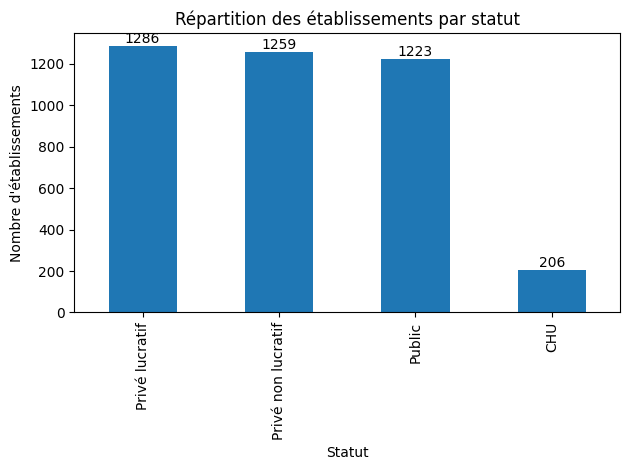

In [26]:
counts = FINESS["Statut"].value_counts()
ax = counts.plot(kind="bar")

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom"
    )

plt.title("Répartition des établissements par statut")
plt.xlabel("Statut")
plt.ylabel("Nombre d'établissements")

plt.tight_layout()
plt.show()

In [27]:
dummies = pd.get_dummies(Data["Statut"], prefix="Statut")

Data["Statut_PNL"] = dummies["Statut_Privé non lucratif"]
Data["Statut_PL"]  = dummies["Statut_Privé lucratif"]
Data["Statut_CHU"] = dummies["Statut_CHU"]

Data["Statut_PNL"] = Data["Statut_PNL"].astype(int)
Data["Statut_PL"]  = Data["Statut_PL"].astype(int)
Data["Statut_CHU"] = Data["Statut_CHU"].astype(int)

Catégorisation des variables :

In [28]:
inputs = ["lMED", "lIDE", "lAID", "lADMIN"]
outputs = ["lURG", "lMCO_HP","lMCO_HC", "lSSR", "lPSY","lSEANCES", "lUSLD"]
controles_statut = ["Statut_PNL", "Statut_PL","Statut_CHU"] 
controles_services = ["I_PSY", "I_SSR", "I_URG", "I_USLD","I_SEANCES", "I_MCO"]
controles_autres= ["lduree_MCO"]
controles_hospidiag = ["A9_imp_2022"]
interactions_statut = [f"{var}_PNL" for var in outputs] + [f"{var}_PL" for var in outputs] + [f"{var}_CHU" for var in outputs]

Ajout de variables d'outputs liées aux différentes catégories d'établissement contrôlées ("termes d'interaction") :

In [29]:
for var in outputs:
    Data[f"{var}_PNL"] = Data[var] * Data["Statut_PNL"]
    Data[f"{var}_PL"]  = Data[var] * Data["Statut_PL"]
    Data[f"{var}_CHU"]  = Data[var] * Data["Statut_CHU"]

Pour mieux mesurer le gain d'efficacité lié à la réduction de la durée des séjours, on construit la variable "lduree_MCO" contient la durée moyenne d'un séjour en hospitalisation complète en log.

In [30]:
Data["duree_MCO"] = SYGEN2022['JOU_MCO']/SYGEN2022['SEJHC_MCO']
Data["duree_MCO"] = Data["duree_MCO"].fillna(0)
Data["lduree_MCO"] = np.log(Data["duree_MCO"]+1)

On souhaite également contrôler pour la gravité des cas, pour cela on utilise l'indicateur A9 d'Hospidiag

Ajout des valeurs imputées de l'indicateur de gravité A9 d'hospidiag : 

In [31]:
A9_imputed = pd.read_csv("A9_imputed2022.csv", sep=",", decimal = ".", encoding="utf-8")
A9_imputed

,FI,A9_imp_2022
0,010000024,11.360
1,010000032,18.320
2,010000065,54.820
3,010000081,13.276
4,010000099,59.410
...,...,...
3983,980500763,0.000
3984,980500920,12.868
3985,980501159,13.474
3986,980501258,13.474


In [32]:
Data = Data.merge(A9_imputed, on="FI", how="left")

### 4 - Première approche : régression linéaire en contrôlant pour le statut

#### 4.1 - Estimation des coefficients de la demande conditionnelle

Préparation des données à la régression : 

In [33]:
X_vars = (outputs + controles_statut + controles_services + controles_autres + interactions_statut)

Data_clean = Data[inputs + X_vars].copy()

# Conversion forcée en numérique
Data_clean = Data_clean.apply(pd.to_numeric, errors="coerce")

# Suppression des lignes inexploitables
Data_clean = Data_clean.dropna()

Data_clean.describe()

,lMED,lIDE,lAID,lADMIN,lURG,lMCO_HP,lMCO_HC,lSSR,lPSY,lSEANCES,...,lPSY_PL,lSEANCES_PL,lUSLD_PL,lURG_CHU,lMCO_HP_CHU,lMCO_HC_CHU,lSSR_CHU,lPSY_CHU,lSEANCES_CHU,lUSLD_CHU
count,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,...,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000
mean,2.942552,3.741972,3.593996,3.078617,2.112241,3.054052,3.672775,3.293943,1.350216,1.772571,...,0.360630,0.524203,0.014384,0.289539,0.407115,0.441251,0.196546,0.120006,0.284613,0.052456
std,1.423007,1.335277,1.266089,1.271355,4.153378,4.062759,4.083718,3.029485,3.115397,3.480993,...,1.681759,2.021747,0.210497,1.750673,1.853759,1.961656,1.090230,0.971786,1.605925,0.436421
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.791759,2.708050,2.772589,2.197225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.564949,3.465736,3.496508,2.890372,0.000000,0.000000,0.000000,5.017280,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.094345,4.624973,4.406719,3.891820,0.000000,7.934507,7.954537,6.102559,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,7.323831,7.645398,7.515889,6.859615,11.793915,10.914525,11.235352,7.921536,10.761492,11.306553,...,10.141559,11.029699,3.931826,11.793915,10.698085,11.235352,7.819636,10.328723,11.273551,5.123964


On va donc réaliser une estimation à partir de 2975 observations sur l'année 2022 (sur les 3988 observations disponibles), soit une utilisation 75%.

Estimation des coefficients : On régresse les inputs (médecins, infirmiers, aides soignantes, personnel adminisitratif) sur les outputs et les contrôles

In [34]:
results = {}
dict_diff = {}

In [35]:
for inp in inputs:
    y = Data_clean[inp]

    X = Data_clean[X_vars]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results[inp] = model

In [36]:
for inp, model in results.items():
    for statut in ["PNL", "PL", "CHU"]:
        coef_name = f"Statut_{statut}"

        if coef_name in model.params.index:
            coef = model.params[coef_name]
            pct = (np.exp(coef) - 1) * 100
            dict_diff[(inp, statut)] = pct

#### 4.2 - Résultats

In [37]:
dict_diff

{('lMED', 'PNL'): np.float64(14.516245628353497),
 ('lMED', 'PL'): np.float64(21.445510576000082),
 ('lMED', 'CHU'): np.float64(54.04456137341867),
 ('lIDE', 'PNL'): np.float64(-6.206234428184398),
 ('lIDE', 'PL'): np.float64(-11.25951885113733),
 ('lIDE', 'CHU'): np.float64(161.52391400862024),
 ('lAID', 'PNL'): np.float64(-43.9320164419115),
 ('lAID', 'PL'): np.float64(-45.8756086985962),
 ('lAID', 'CHU'): np.float64(87.21680141945698),
 ('lADMIN', 'PNL'): np.float64(28.83443712770084),
 ('lADMIN', 'PL'): np.float64(4.121211335604502),
 ('lADMIN', 'CHU'): np.float64(6.341168968421074)}

|    |    Privé Lucratif     |   Privé non lucratif    |    CHU   |
|:----------|------------:|-------------:|-------------:|
| Personnel administratif    |      +4.1% |        +28.8% |    +6.3%     |
| Aides-soigant.e.s      |      -45.9% |     -43.9%  |      +87.2%   |
| Infirmièr.e.s      |      -11.3% |       -6.2% |    +161.5%      |
| Médecins      |      +14.5% |     +21.4%    |       +54%  |

Tableau regroupant les différences d'emploi des différentes catégories de personnel à niveau de production égal selon la nature de l'etablissement (privé non lucratif,privé lucratif ou CHU) en prenant comme référence les hopitaux publics petits ou moyens (non CHU).

Contrôles : présence de service d'urgence, de MCO, de psychiatrie, de SSR, d'USLD, et de séances ; durée moyenne de séjour en MCO

Contrôles à rajouter : indice de recherche/enseignement (hospidiag), indice de gravité A9 d'hospidiag

/!\ les résultats ne sont pas statistiquement significatifs pour le personnel administratif (cf pvalues)

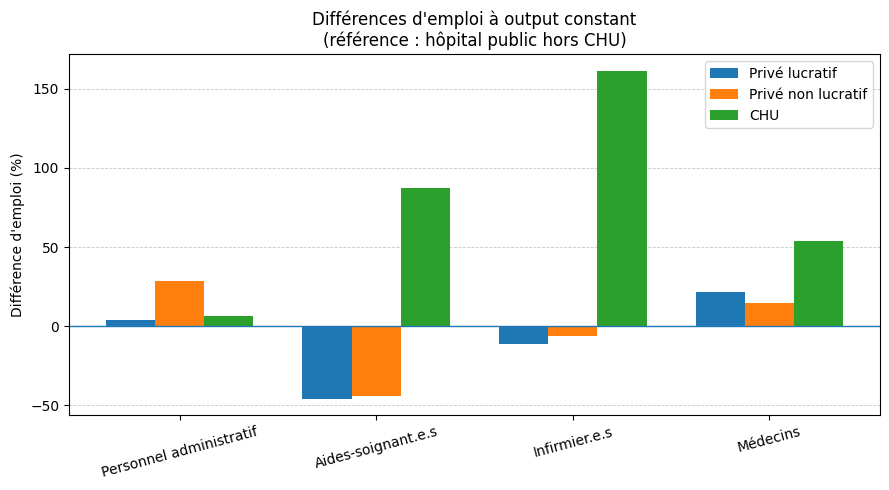

In [38]:
# Passage du dictionnaire à un DataFrame
df = pd.Series(dict_diff).unstack()

# On garde l'ordre souhaité
df = df.loc[["lADMIN", "lAID", "lIDE", "lMED"], ["PL", "PNL", "CHU"]]

# Renommage lisible
df.index = [
    "Personnel administratif",
    "Aides-soignant.e.s",
    "Infirmier.e.s",
    "Médecins"
]

df.columns = [
    "Privé lucratif",
    "Privé non lucratif",
    "CHU"
]

# Paramètres du graphique
x = np.arange(len(df.index))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

ax.yaxis.grid(True,linestyle="--",linewidth=0.6,alpha=0.7)
ax.set_axisbelow(True)

ax.bar(x - width, df["Privé lucratif"], width, label="Privé lucratif")
ax.bar(x, df["Privé non lucratif"], width, label="Privé non lucratif")
ax.bar(x + width, df["CHU"], width, label="CHU")



# Mise en forme
ax.set_ylabel("Différence d'emploi (%)")
ax.set_title(
    "Différences d'emploi à output constant\n"
    "(référence : hôpital public hors CHU)"
)
ax.set_xticks(x)
ax.set_xticklabels(df.index, rotation=15)
ax.legend()

ax.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

Evaluation des régression : R²

In [39]:
for inp, model in results.items():
    print(f"{inp} : R² = {model.rsquared:.3f} | R² ajusté = {model.rsquared_adj:.3f}")

lMED : R² = 0.829 | R² ajusté = 0.827
lIDE : R² = 0.792 | R² ajusté = 0.789
lAID : R² = 0.713 | R² ajusté = 0.710
lADMIN : R² = 0.740 | R² ajusté = 0.736


Concernant l'influence mesurée de la durée moyenne des séjours :

In [40]:
for inp, model in results.items():
    print(f"\n{inp}")
    print(model.params["lduree_MCO"])


lMED
-0.20495693412849342

lIDE
-0.06582118722636235

lAID
0.08288867773675407

lADMIN
-0.10061983366540846


Coefficients négatifs ? Très surprenant 

Effet de l'ambulatoire sur les différentes catégories de personnel :

In [41]:
for inp, model in results.items():
    print(f"{inp} : Hospitalisation complète : {model.params["lMCO_HC"]} | Hospitalisation partielle : {model.params["lMCO_HP"]}")

lMED : Hospitalisation complète : 0.25242505613159966 | Hospitalisation partielle : 0.07998806847785249
lIDE : Hospitalisation complète : 0.20659592751617525 | Hospitalisation partielle : 0.07154330702545428
lAID : Hospitalisation complète : 0.161423070327391 | Hospitalisation partielle : 0.05653212199508989
lADMIN : Hospitalisation complète : 0.20074119009799832 | Hospitalisation partielle : 0.05173508739951181


Résultats complets des régressions :

In [42]:
results["lMED"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   lMED   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     473.9
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:24:30   Log-Likelihood:                -2616.8
No. Observations:                2948   AIC:                             5312.
Df Residuals:                    2909   BIC:                             5545.
Df Model:                          38                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.6916      0.048     35.526      0.000       1.598       1.785
lURG             0.3124      0.056      5.608      0.000       0.203       0.422
lMCO_HP          0.0800      0.010      7.895      0.000       0.060       0.100
lMCO_HC          0.2524      0.018     14.177      0.000       0.218       0.287
lSSR             0.2836      0.024     11.616      0.000       0.236       0.331
lPSY             0.3856      0.029     13.397      0.000       0.329       0.442
lSEANCES         0.0614      0.015      4.033      0.000       0.032       0.091
lUSLD           -0.0086      0.040     -0.213      0.831      -0.088       0.071
Statut_PNL       0.1355      0.073      1.859      0.063      -0.007       0.278
Statut_PL        0.1943      0.074      2.611      0.009       0.048       0.340
Statut_CHU       0.4321      0.180      2.395      0.017       0.078       0.786
I_PSY           -2.1361      0.242     -8.839      0.000      -2.610      -1.662
I_SSR           -1.5384      0.140    -10.961      0.000      -1.813      -1.263
I_URG           -2.6836      0.492     -5.456      0.000      -3.648      -1.719
I_USLD          -0.1528      0.134     -1.143      0.253      -0.415       0.109
I_SEANCES       -0.4730      0.096     -4.943      0.000      -0.661      -0.285
I_MCO           -0.4064      0.105     -3.855      0.000      -0.613      -0.200
lduree_MCO      -0.2050      0.039     -5.238      0.000      -0.282      -0.128
lURG_PNL        -0.0198      0.015     -1.314      0.189      -0.049       0.010
lMCO_HP_PNL      0.0205      0.018      1.165      0.244      -0.014       0.055
lMCO_HC_PNL      0.0013      0.016      0.083      0.934      -0.029       0.032
lSSR_PNL        -0.0020      0.012     -0.170      0.865      -0.025       0.021
lPSY_PNL        -0.0089      0.013     -0.709      0.478      -0.034       0.016
lSEANCES_PNL     0.0419      0.015      2.867      0.004       0.013       0.071
lUSLD_PNL       -0.0160      0.027     -0.587      0.557      -0.070       0.038
lURG_PL         -0.0218      0.013     -1.700      0.089      -0.047       0.003
lMCO_HP_PL       0.0664      0.020      3.388      0.001       0.028       0.105
lMCO_HC_PL      -0.0531      0.020     -2.637      0.008      -0.093      -0.014
lSSR_PL         -0.0081      0.011     -0.720      0.471      -0.030       0.014
lPSY_PL         -0.0587      0.011     -5.430      0.000      -0.080      -0.037
lSEANCES_PL      0.0154      0.012      1.315      0.189      -0.008       0.038
lUSLD_PL         0.0294      0.033      0.880      0.379      -0.036       0.095
lURG_CHU        -0.0007      0.018     -0.040      0.968      -0.036       0.035
lMCO_HP_CHU      0.0812      0.028      2.933      0.003       0.027       0.136
lMCO_HC_CHU     -0.0739      0.030     -2.436      0.015      -0.133      -0.014
lSSR_

In [43]:
results["lIDE"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   lIDE   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     308.5
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:24:31   Log-Likelihood:                -2721.4
No. Observations:                2948   AIC:                             5521.
Df Residuals:                    2909   BIC:                             5754.
Df Model:                          38                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.7691      0.051     54.388      0.000       2.669       2.869
lURG             0.3016      0.068      4.467      0.000       0.169       0.434
lMCO_HP          0.0715      0.011      6.728      0.000       0.051       0.092
lMCO_HC          0.2066      0.021      9.927      0.000       0.166       0.247
lSSR             0.2984      0.027     11.043      0.000       0.245       0.351
lPSY             0.4795      0.032     15.050      0.000       0.417       0.542
lSEANCES         0.0845      0.019      4.543      0.000       0.048       0.121
lUSLD            0.1227      0.040      3.075      0.002       0.044       0.201
Statut_PNL      -0.0641      0.081     -0.791      0.429      -0.223       0.095
Statut_PL       -0.1195      0.079     -1.510      0.131      -0.274       0.036
Statut_CHU       0.9614      0.185      5.200      0.000       0.599       1.324
I_PSY           -2.4849      0.266     -9.349      0.000      -3.006      -1.964
I_SSR           -1.6859      0.154    -10.937      0.000      -1.988      -1.384
I_URG           -2.4658      0.583     -4.231      0.000      -3.608      -1.324
I_USLD          -0.3210      0.132     -2.437      0.015      -0.579      -0.063
I_SEANCES       -0.5869      0.107     -5.488      0.000      -0.797      -0.377
I_MCO           -0.7865      0.140     -5.615      0.000      -1.061      -0.512
lduree_MCO      -0.0658      0.041     -1.617      0.106      -0.146       0.014
lURG_PNL        -0.0085      0.017     -0.500      0.617      -0.042       0.025
lMCO_HP_PNL     -0.0036      0.020     -0.180      0.857      -0.042       0.035
lMCO_HC_PNL      0.0260      0.016      1.589      0.112      -0.006       0.058
lSSR_PNL         0.0170      0.013      1.304      0.192      -0.009       0.043
lPSY_PNL        -0.0009      0.016     -0.058      0.953      -0.032       0.030
lSEANCES_PNL     0.0289      0.017      1.674      0.094      -0.005       0.063
lUSLD_PNL       -0.0476      0.027     -1.765      0.078      -0.100       0.005
lURG_PL         -0.0142      0.015     -0.927      0.354      -0.044       0.016
lMCO_HP_PL       0.0164      0.019      0.862      0.388      -0.021       0.054
lMCO_HC_PL      -0.0306      0.019     -1.631      0.103      -0.067       0.006
lSSR_PL         -0.0007      0.012     -0.063      0.950      -0.024       0.023
lPSY_PL         -0.0906      0.012     -7.840      0.000      -0.113      -0.068
lSEANCES_PL      0.0376      0.014      2.662      0.008       0.010       0.065
lUSLD_PL        -0.0461      0.041     -1.130      0.258      -0.126       0.034
lURG_CHU        -0.0039      0.020     -0.194      0.847      -0.044       0.036
lMCO_HP_CHU      0.0355      0.028      1.267      0.205      -0.019       0.090
lMCO_HC_CHU     -0.0658      0.029     -2.244      0.025      -0.123      -0.008
lSSR_

In [44]:
results["lAID"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   lAID   R-squared:                       0.713
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     249.8
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:24:31   Log-Likelihood:                -3035.8
No. Observations:                2948   AIC:                             6150.
Df Residuals:                    2909   BIC:                             6383.
Df Model:                          38                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.8005      0.053     52.815      0.000       2.697       2.904
lURG             0.4061      0.064      6.354      0.000       0.281       0.531
lMCO_HP          0.0565      0.012      4.536      0.000       0.032       0.081
lMCO_HC          0.1614      0.023      7.028      0.000       0.116       0.206
lSSR             0.3286      0.029     11.492      0.000       0.273       0.385
lPSY             0.2932      0.034      8.589      0.000       0.226       0.360
lSEANCES         0.0758      0.018      4.191      0.000       0.040       0.111
lUSLD            0.1387      0.038      3.609      0.000       0.063       0.214
Statut_PNL      -0.5786      0.082     -7.053      0.000      -0.739      -0.418
Statut_PL       -0.6139      0.081     -7.607      0.000      -0.772      -0.456
Statut_CHU       0.6271      0.246      2.554      0.011       0.146       1.108
I_PSY           -1.7774      0.293     -6.062      0.000      -2.352      -1.203
I_SSR           -1.5925      0.165     -9.665      0.000      -1.915      -1.270
I_URG           -3.4280      0.553     -6.198      0.000      -4.512      -2.344
I_USLD           0.0227      0.124      0.183      0.855      -0.221       0.267
I_SEANCES       -0.5201      0.109     -4.757      0.000      -0.734      -0.306
I_MCO           -0.9432      0.161     -5.870      0.000      -1.258      -0.628
lduree_MCO       0.0829      0.046      1.795      0.073      -0.008       0.173
lURG_PNL        -0.0096      0.018     -0.544      0.587      -0.044       0.025
lMCO_HP_PNL      0.0048      0.023      0.210      0.834      -0.040       0.049
lMCO_HC_PNL      0.0398      0.019      2.121      0.034       0.003       0.077
lSSR_PNL         0.0693      0.013      5.174      0.000       0.043       0.096
lPSY_PNL         0.0353      0.020      1.758      0.079      -0.004       0.075
lSEANCES_PNL     0.0246      0.016      1.530      0.126      -0.007       0.056
lUSLD_PNL        0.0529      0.030      1.738      0.082      -0.007       0.113
lURG_PL         -0.0059      0.015     -0.385      0.700      -0.036       0.024
lMCO_HP_PL       0.0031      0.023      0.135      0.892      -0.042       0.048
lMCO_HC_PL      -0.0067      0.023     -0.295      0.768      -0.051       0.038
lSSR_PL          0.0424      0.012      3.487      0.000       0.019       0.066
lPSY_PL         -0.0292      0.012     -2.447      0.014      -0.053      -0.006
lSEANCES_PL      0.0409      0.014      2.939      0.003       0.014       0.068
lUSLD_PL         0.0535      0.037      1.451      0.147      -0.019       0.126
lURG_CHU        -0.0211      0.021     -1.027      0.304      -0.061       0.019
lMCO_HP_CHU      0.0654      0.030      2.189      0.029       0.007       0.124
lMCO_HC_CHU     -0.0481      0.034     -1.413      0.158      -0.115       0.019
lSSR_

In [45]:
results["lADMIN"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lADMIN   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     255.8
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:24:31   Log-Likelihood:                -2905.9
No. Observations:                2948   AIC:                             5890.
Df Residuals:                    2909   BIC:                             6123.
Df Model:                          38                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.9305      0.058     33.471      0.000       1.817       2.044
lURG             0.2800      0.062      4.494      0.000       0.158       0.402
lMCO_HP          0.0517      0.012      4.159      0.000       0.027       0.076
lMCO_HC          0.2007      0.021      9.508      0.000       0.159       0.242
lSSR             0.2306      0.027      8.416      0.000       0.177       0.284
lPSY             0.3940      0.032     12.456      0.000       0.332       0.456
lSEANCES         0.1032      0.018      5.797      0.000       0.068       0.138
lUSLD           -0.0150      0.050     -0.300      0.765      -0.113       0.083
Statut_PNL       0.2534      0.082      3.098      0.002       0.093       0.414
Statut_PL        0.0404      0.072      0.558      0.577      -0.102       0.182
Statut_CHU       0.0615      0.261      0.236      0.814      -0.450       0.573
I_PSY           -2.1574      0.265     -8.152      0.000      -2.676      -1.639
I_SSR           -1.1558      0.156     -7.407      0.000      -1.462      -0.850
I_URG           -2.2392      0.541     -4.142      0.000      -3.299      -1.179
I_USLD          -0.0473      0.165     -0.286      0.775      -0.371       0.277
I_SEANCES       -0.6661      0.104     -6.396      0.000      -0.870      -0.462
I_MCO           -0.3475      0.131     -2.655      0.008      -0.604      -0.091
lduree_MCO      -0.1006      0.043     -2.356      0.018      -0.184      -0.017
lURG_PNL        -0.0216      0.018     -1.199      0.231      -0.057       0.014
lMCO_HP_PNL      0.0314      0.020      1.572      0.116      -0.008       0.070
lMCO_HC_PNL     -0.0434      0.016     -2.726      0.006      -0.075      -0.012
lSSR_PNL         0.0426      0.013      3.165      0.002       0.016       0.069
lPSY_PNL         0.0092      0.015      0.613      0.540      -0.020       0.038
lSEANCES_PNL     0.0581      0.018      3.294      0.001       0.024       0.093
lUSLD_PNL       -0.0208      0.029     -0.713      0.476      -0.078       0.036
lURG_PL         -0.0229      0.014     -1.584      0.113      -0.051       0.005
lMCO_HP_PL       0.0326      0.018      1.838      0.066      -0.002       0.067
lMCO_HC_PL      -0.0701      0.018     -3.941      0.000      -0.105      -0.035
lSSR_PL          0.0112      0.011      0.996      0.319      -0.011       0.033
lPSY_PL         -0.0753      0.010     -7.187      0.000      -0.096      -0.055
lSEANCES_PL      0.0079      0.013      0.610      0.542      -0.018       0.033
lUSLD_PL         0.0165      0.045      0.370      0.712      -0.071       0.104
lURG_CHU         0.0049      0.021      0.239      0.811      -0.036       0.046
lMCO_HP_CHU      0.1324      0.037      3.599      0.000       0.060       0.204
lMCO_HC_CHU     -0.1008      0.042     -2.374      0.018      -0.184      -0.018
lSSR_

Dans tous les cas, on constate que les coefficients associés au statut (PL,PNL ou CHU) affichent une forte significativité statistique, ce qui vient donner une certaine robustesse aux resultats. Voyons tout de même si l'on trouve des résultats identiques en procédant à des régressions séparées.

### 5 - Deuxième approche : régressions linéaires séparées pour chaque catégorie d'établissement

#### 5.1 - Séparation des données en quatre selon le statut de l'établissement :

In [46]:
Data_CHU = Data[Data["Statut"] == "CHU"]
Data_PNL = Data[Data["Statut"] == "Privé non lucratif"]
Data_PL = Data[Data["Statut"] == "Privé lucratif"]
Data_PHP = Data[Data["Statut"] == "Public"]

#### 5.2 - Préparation des données :

In [47]:
X_vars2 = (outputs + controles_services + controles_autres + controles_hospidiag)

In [48]:
Data_CHU_clean = Data_CHU[inputs + X_vars2].copy()
Data_CHU_clean = Data_CHU_clean.apply(pd.to_numeric, errors="coerce") # Conversion forcée en numérique
Data_CHU_clean = Data_CHU_clean.dropna() # Suppression des lignes inexploitables
Data_CHU_clean.describe()

,lMED,lIDE,lAID,lADMIN,lURG,lMCO_HP,lMCO_HC,lSSR,lPSY,lSEANCES,lUSLD,I_PSY,I_SSR,I_URG,I_USLD,I_SEANCES,I_MCO,lduree_MCO,A9_imp_2022
count,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000
mean,4.535845,5.456158,5.349676,4.351697,4.849784,6.819177,7.390950,3.292152,2.010105,4.767274,0.878638,0.261364,0.539773,0.448864,0.250000,0.528409,0.875000,1.743273,12.297057
std,1.641376,1.392721,1.265897,1.671700,5.419373,3.727535,3.625398,3.125160,3.475940,4.683810,1.573955,0.440631,0.499838,0.498797,0.434248,0.500617,0.331662,0.866378,5.700886
min,0.693147,1.945910,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.030000
25%,3.124381,4.248495,4.494191,3.044522,0.000000,5.742036,6.396044,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.660443,10.110000
50%,4.639467,5.523457,5.498962,4.605120,0.000000,8.445588,8.603625,4.543295,0.000000,6.228739,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.891958,11.225000
75%,6.019807,6.729222,6.391879,5.871377,10.917097,9.518097,10.132258,6.210994,4.909889,9.484843,0.486478,1.000000,1.000000,1.000000,0.250000,1.000000,1.000000,2.181796,12.450000
max,7.323831,7.645398,7.515889,6.859615,11.793915,10.698085,11.235352,7.819636,10.328723,11.273551,5.123964,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.422965,40.710000


In [49]:
Data_PL_clean = Data_PL[inputs + X_vars2].copy()
Data_PL_clean = Data_PL_clean.apply(pd.to_numeric, errors="coerce") # Conversion forcée en numérique
Data_PL_clean = Data_PL_clean.dropna() # Suppression des lignes inexploitables
Data_PL_clean.describe()

,lMED,lIDE,lAID,lADMIN,lURG,lMCO_HP,lMCO_HC,lSSR,lPSY,lSEANCES,lUSLD,I_PSY,I_SSR,I_URG,I_USLD,I_SEANCES,I_MCO,lduree_MCO,A9_imp_2022
count,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000
mean,3.018576,3.499093,3.127641,2.822357,1.232683,3.686750,3.498014,2.801581,1.123823,1.633563,0.044826,0.140592,0.438689,0.123679,0.015856,0.208245,0.449260,0.670266,11.468444
std,1.210379,0.952124,0.944242,0.824897,3.287617,4.421750,4.055306,3.199175,2.821621,3.306463,0.369881,0.347784,0.496489,0.329389,0.124985,0.406268,0.497682,0.805304,9.957827
min,0.000000,0.693147,0.000000,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.945910,2.833213,2.484907,2.197225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.610000
50%,2.708050,3.367296,3.178054,2.708050,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.967000
75%,4.123069,4.127134,3.761200,3.401197,0.000000,8.874553,7.981306,6.388141,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.469342,16.132000
max,5.641907,6.208590,5.891644,5.117994,11.174652,10.914525,10.290857,7.798523,10.141559,11.029699,3.931826,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.874667,85.380000


In [50]:
Data_PNL_clean = Data_PNL[inputs + X_vars2].copy()
Data_PNL_clean = Data_PNL_clean.apply(pd.to_numeric, errors="coerce") # Conversion forcée en numérique
Data_PNL_clean = Data_PNL_clean.dropna() # Suppression des lignes inexploitables
Data_PNL_clean.describe()

,lMED,lIDE,lAID,lADMIN,lURG,lMCO_HP,lMCO_HC,lSSR,lPSY,lSEANCES,lUSLD,I_PSY,I_SSR,I_URG,I_USLD,I_SEANCES,I_MCO,lduree_MCO,A9_imp_2022
count,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000
mean,2.458146,3.318888,3.138190,2.920821,0.493618,1.500290,1.796949,3.363196,0.766529,0.863542,0.228877,0.098529,0.547059,0.048529,0.073529,0.098529,0.245588,0.486017,17.005903
std,1.174006,1.112570,1.121619,1.086999,2.191795,3.189822,3.314464,3.105725,2.379750,2.695647,0.830352,0.298249,0.498147,0.215040,0.261196,0.298249,0.430752,0.919495,10.564443
min,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.609438,2.564949,2.397895,2.197225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.512000
50%,2.079442,3.178054,3.218876,2.833213,0.000000,0.000000,0.000000,5.233747,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.778000
75%,3.044522,3.891820,3.871201,3.496508,0.000000,0.000000,0.000000,6.250939,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.200000
max,6.253829,6.655440,6.188264,6.276643,11.466002,10.614499,10.658929,7.921536,10.192681,11.306553,4.094345,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.932230,53.424000


In [51]:
Data_PHP_clean = Data_PHP[inputs + X_vars2].copy()
Data_PHP_clean = Data_PHP_clean.apply(pd.to_numeric, errors="coerce") # Conversion forcée en numérique
Data_PHP_clean = Data_PHP_clean.dropna() # Suppression des lignes inexploitables
Data_PHP_clean.describe()

,lMED,lIDE,lAID,lADMIN,lURG,lMCO_HP,lMCO_HC,lSSR,lPSY,lSEANCES,lUSLD,I_PSY,I_SSR,I_URG,I_USLD,I_SEANCES,I_MCO,lduree_MCO,A9_imp_2022
count,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
mean,2.969625,3.997344,4.064795,3.239833,3.565492,2.939879,4.504255,3.710486,1.823995,2.043021,1.259548,0.208333,0.655556,0.350000,0.388889,0.256481,0.603704,1.289715,20.806139
std,1.497282,1.461235,1.170082,1.470207,4.879014,3.775402,4.012500,2.751318,3.602783,3.594510,1.628804,0.406305,0.475407,0.477191,0.487724,0.436893,0.489354,1.140179,14.808105
min,0.000000,0.693147,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.609438,2.708050,3.258097,2.079442,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.400000
50%,2.772589,3.713572,3.988984,3.113268,0.000000,0.000000,5.409409,5.308268,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.738610,14.820000
75%,4.234107,5.298317,4.884689,4.502572,9.714420,7.472784,8.357611,5.852920,0.000000,4.237704,3.044522,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.119583,22.940000
max,6.368187,7.138073,6.824374,6.466145,11.624735,9.871790,10.838953,7.560080,10.761492,11.015970,4.753590,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.562466,94.740000


On va donc réaliser des régressions linéaires sur des jeux de données de 192 à 1118 lignes

#### 5.3 - Estimations par catégorie d'établissement

Estimation de la fonction de demande conditionnelle des CHU :

In [52]:
results_CHU = {}

for inp in inputs:
    y = Data_CHU_clean[inp]

    X = Data_CHU_clean[X_vars2]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results_CHU[inp] = model

Estimation de la fonction de demande conditionnelle des établissements privés à but lucratif :

In [53]:
results_PL = {}

for inp in inputs:
    y = Data_PL_clean[inp]

    X = Data_PL_clean[X_vars2]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results_PL[inp] = model

Estimation de la fonction de demande conditionnelle des établissements privés à but non lucratif :

In [54]:
results_PNL = {}

for inp in inputs:
    y = Data_PNL_clean[inp]

    X = Data_PNL_clean[X_vars2]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results_PNL[inp] = model

Estimation de la fonction de demande conditionnelle des établissements publics non CHU :

In [55]:
results_PHP = {}

for inp in inputs:
    y = Data_PHP_clean[inp]

    X = Data_PHP_clean[X_vars2]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results_PHP[inp] = model

[A suivre]

### 6 - Analyse causale par variables instrumentales

Utilisation des données de 2019 comme instruments

#### 6.1 - Préparation des données

Extraction des données :

In [56]:
SYGEN2019 = pd.read_csv("SAE/2019/SYGEN_2019.csv", sep=";", encoding="latin-1")
Data2019 = SYGEN2019[['FI','FI_EJ','EFFSAL_TOT','EFFLIB_TOT','EFF_INFSANSSPE','EFF_INFAVECSPE','EFF_AID','EFF_DIR','EFF_AUTADM','SEJHC_SSR','SEJHC_MCO','SEJHP_MCO','SEJ_HTP_TOT','VEN_HDJ_TOT','VEN_HDN_TOT','SEAN_HEMO_CENTRE','SEAN_CHIMIO','SEAN_RADIO']]
Data2019 = Data2019.merge(FINESS, on="FI", how="left")

In [57]:
Urg2019 = pd.read_csv("SAE/2019/URGENCES2_2019.csv", sep=";", encoding="latin-1")
Urg2019 = Urg2019[['FI','PASSU']]
Urg2019 = Urg2019.groupby("FI").sum().reset_index()
Data2019 = Data2019.merge(Urg2019, on="FI", how="left")

In [58]:
USLD2019 = pd.read_csv("SAE/2019/USLD_2019.csv", sep=";", encoding="latin-1")
USLD2019 = USLD2019[['FI','ENT']]
Data2019 = Data2019.merge(USLD2019, on="FI", how="left")

Catégorie de personnel (Inputs) :

In [59]:
Data2019['EFF_MED'] = Data2019['EFFSAL_TOT'] + Data2019['EFFLIB_TOT'].fillna(0)
Data2019['EFF_IDE'] = Data2019['EFF_INFSANSSPE'] + Data2019['EFF_INFAVECSPE'].fillna(0)
Data2019['EFF_ADMIN'] = Data2019['EFF_AUTADM'] + Data2019['EFF_DIR'].fillna(0)

Outputs :

In [60]:
Data2019['PSY'] = Data2019['SEJ_HTP_TOT'] + Data2019['VEN_HDJ_TOT'].fillna(0) + Data2019['VEN_HDN_TOT'].fillna(0)
Data2019['PSY'] = Data2019['PSY'].fillna(0)
Data2019['I_PSY_2019'] = (Data2019['PSY'] > 0).astype(int)

Data2019['MCO'] = Data2019['SEJHP_MCO'] + Data2019['SEJHC_MCO']
Data2019['MCO'] = Data2019['MCO'].fillna(0)
Data2019['I_MCO_2019'] = (Data2019['MCO'] > 0).astype(int)

Data2019['SEANCES'] = Data2019['SEAN_HEMO_CENTRE'].fillna(0) + Data2019['SEAN_CHIMIO'] + Data2019['SEAN_RADIO'].fillna(0)
Data2019['SEANCES'] = Data2019['SEANCES'].fillna(0)
Data2019['I_SEANCES_2019'] = (Data2019['SEANCES'] > 0).astype(int)

Data2019['PASSU'] = Data2019['PASSU'].fillna(0)
Data2019['I_URG_2019'] = (Data2019['PASSU'] > 0).astype(int)

Data2019['ENT'] = Data2019['ENT'].fillna(0)
Data2019['I_USLD_2019'] = (Data2019['ENT'] > 0).astype(int)

Data2019['SEJHC_SSR'] = Data2019['SEJHC_SSR'].fillna(0)
Data2019['I_SSR_2019'] = (Data2019['SEJHC_SSR'] > 0).astype(int)

Passage au log :

In [61]:
Data2019['lURG_2019'] = np.log(Data2019['PASSU']+1)
Data2019['lMCO_HC_2019'] = np.log(SYGEN2019['SEJHC_MCO'].fillna(0)+1)
Data2019['lMCO_HP_2019'] = np.log(SYGEN2019['SEJHP_MCO'].fillna(0)+1)
Data2019['lPSY_2019'] = np.log(Data2019['PSY']+1)
Data2019['lSSR_2019'] = np.log(Data2019['SEJHC_SSR']+1)
Data2019['lSEANCES_2019'] = np.log(Data2019['SEANCES']+1)
Data2019['lUSLD_2019'] = np.log(Data2019['ENT']+1)

Data2019['lMED_2019'] = np.log(Data2019['EFF_MED']+1)
Data2019['lIDE_2019'] = np.log(Data2019['EFF_IDE']+1)
Data2019['lAID_2019'] = np.log(Data2019['EFF_AID']+1)
Data2019['lADMIN_2019'] = np.log(Data2019['EFF_ADMIN']+1)

Indicatrices de statut :

In [62]:
dummies_2019 = pd.get_dummies(Data2019['Statut'], prefix='Statut')

Data2019['Statut_PNL_2019'] = dummies_2019['Statut_Privé non lucratif']
Data2019['Statut_PL_2019']  = dummies_2019['Statut_Privé lucratif']
Data2019['Statut_CHU_2019'] = dummies_2019['Statut_CHU']

Data2019['Statut_PNL_2019'] = Data2019['Statut_PNL_2019'].astype(int)
Data2019['Statut_PL_2019']  = Data2019['Statut_PL_2019'].astype(int)
Data2019['Statut_CHU_2019'] = Data2019['Statut_CHU_2019'].astype(int)

Hospidiag :

In [63]:
A9_imputed_2019 = pd.read_csv("A9_imputed2019.csv", sep=",", decimal = ".", encoding="utf-8")
Data2019 = Data2019.merge(A9_imputed_2019, on="FI", how="left")

Durée séjours MCO :

In [64]:
dureeMCO_2019 = SYGEN2019['JOU_MCO']/SYGEN2019['SEJHC_MCO']
Data2019["duree_MCO_2019"] = dureeMCO_2019.fillna(0)
Data2019["lduree_MCO_2019"] = np.log(Data2019["duree_MCO_2019"]+1)

Interactions :

In [65]:
for var in ["lURG_2019", "lMCO_HC_2019","lMCO_HP_2019", "lSSR_2019", "lPSY_2019","lSEANCES_2019", "lUSLD_2019"]:
    Data2019[f"{var}_PNL"] = Data2019[var] * Data2019["Statut_PNL_2019"]
    Data2019[f"{var}_PL"]  = Data2019[var] * Data2019["Statut_PL_2019"]
    Data2019[f"{var}_CHU"]  = Data2019[var] * Data2019["Statut_CHU_2019"]

categorisation des variables :

In [66]:
inputs_2019 = ["lMED_2019","lIDE_2019","lAID_2019","lADMIN_2019"]
outputs_2019 = ["lURG_2019", "lMCO_HC_2019","lMCO_HP_2019", "lSSR_2019", "lPSY_2019","lSEANCES_2019", "lUSLD_2019"]
controles_statut_2019 = ["Statut_PNL_2019", "Statut_PL_2019","Statut_CHU_2019"]
controles_services_2019 = ["I_PSY_2019", "I_SSR_2019", "I_URG_2019", "I_USLD_2019","I_SEANCES_2019", "I_MCO_2019"]
controles_autres_2019= ["lduree_MCO_2019"]
interactions_statut_2019 = [f"{var}_PNL" for var in outputs_2019] + [f"{var}_PL" for var in outputs_2019] + [f"{var}_CHU" for var in outputs_2019]
controles_hospidiag_2019 = ["A9_imp_2019"]

Données utiles :

In [67]:
Data_instr = Data[['FI'] + inputs + outputs + controles_statut + controles_services + controles_autres + interactions_statut + controles_hospidiag]
Data_instr = Data_instr.merge(Data2019[['FI']+inputs_2019 + outputs_2019 + controles_statut_2019 + controles_services_2019 + controles_autres_2019 + interactions_statut_2019 + controles_hospidiag_2019], on="FI", how="inner")
print(Data_instr.shape) 

(3824, 87)


#### 6.2 - Vérification de la pertinence des instruments

Analyse des corrélations entre les variables de 2022 et leurs équivalents de 2019 :

In [68]:
for var in outputs:
    corr = Data_instr[var].corr(Data_instr[f"{var}_2019"])
    print(var, round(corr,3))

lURG 0.989
lMCO_HP 0.98
lMCO_HC 0.991
lSSR 0.978
lPSY 0.982
lSEANCES 0.947
lUSLD 0.966


On observe une corrélation proche de 1 (>0.95), pour chacun des outputs considérés, entre 2019 et 2022, d'où la pertinence d'utiliser les outputs de 2019 comme instruments.

In [69]:
for i in range(len(interactions_statut)):
    var = interactions_statut[i]
    var_2019 = interactions_statut_2019[i]
    corr = Data_instr[var].corr(Data_instr[var_2019])
    print(var, round(corr,3))

lURG_PNL 0.954
lMCO_HP_PNL 0.899
lMCO_HC_PNL 0.883
lSSR_PNL 0.995
lPSY_PNL 0.956
lSEANCES_PNL 0.901
lUSLD_PNL 0.961
lURG_PL 0.99
lMCO_HP_PL 0.948
lMCO_HC_PL 0.946
lSSR_PL 0.988
lPSY_PL 0.989
lSEANCES_PL 0.938
lUSLD_PL 0.969
lURG_CHU 0.994
lMCO_HP_CHU 0.953
lMCO_HC_CHU 0.948
lSSR_CHU 0.971
lPSY_CHU 0.978
lSEANCES_CHU 0.977
lUSLD_CHU 0.945


De façon cohérente, on retrouve une forte corrélation sur les termes d'interaction que l'on va également instrumenter.

In [70]:
Data_instr.columns

Index(['FI', 'lMED', 'lIDE', 'lAID', 'lADMIN', 'lURG', 'lMCO_HP', 'lMCO_HC',
       'lSSR', 'lPSY', 'lSEANCES', 'lUSLD', 'Statut_PNL', 'Statut_PL',
       'Statut_CHU', 'I_PSY', 'I_SSR', 'I_URG', 'I_USLD', 'I_SEANCES', 'I_MCO',
       'lduree_MCO', 'lURG_PNL', 'lMCO_HP_PNL', 'lMCO_HC_PNL', 'lSSR_PNL',
       'lPSY_PNL', 'lSEANCES_PNL', 'lUSLD_PNL', 'lURG_PL', 'lMCO_HP_PL',
       'lMCO_HC_PL', 'lSSR_PL', 'lPSY_PL', 'lSEANCES_PL', 'lUSLD_PL',
       'lURG_CHU', 'lMCO_HP_CHU', 'lMCO_HC_CHU', 'lSSR_CHU', 'lPSY_CHU',
       'lSEANCES_CHU', 'lUSLD_CHU', 'A9_imp_2022', 'lMED_2019', 'lIDE_2019',
       'lAID_2019', 'lADMIN_2019', 'lURG_2019', 'lMCO_HC_2019', 'lMCO_HP_2019',
       'lSSR_2019', 'lPSY_2019', 'lSEANCES_2019', 'lUSLD_2019',
       'Statut_PNL_2019', 'Statut_PL_2019', 'Statut_CHU_2019', 'I_PSY_2019',
       'I_SSR_2019', 'I_URG_2019', 'I_USLD_2019', 'I_SEANCES_2019',
       'I_MCO_2019', 'lduree_MCO_2019', 'lURG_2019_PNL', 'lMCO_HC_2019_PNL',
       'lMCO_HP_2019_PNL', 'lSSR_2019_

In [71]:
Data_instr = Data_instr.dropna()
print(Data_instr.shape)

(2760, 87)


#### 6.3 - Estimations par la méthode des doubles moindres carrés

Estimations en instrumentant les outputs et les termes d'interaction associés :

In [72]:
endog_vars = outputs + interactions_statut
instr_vars = outputs + interactions_statut_2019
controles = controles_statut + controles_services + controles_autres

endog_str = " + ".join(endog_vars)
instr_str = " + ".join(instr_vars)
control_str = " + ".join(controles)

result_instr = {}

for inp in inputs:

    formula = f"""
    {inp} ~ 1
    + {control_str}
    + [{endog_str} ~ {instr_str}]
    """

    model = IV2SLS.from_formula(
        formula,
        data=Data_instr
    )

    res = model.fit(cov_type="robust")

    result_instr[inp] = res

c:\Users\Alexandre\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\shared\linalg.py:64: RuntimeWarning: invalid value encountered in sqrt
  return vecs @ np.diag(1 / np.sqrt(vals)) @ vecs.T
c:\Users\Alexandre\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\shared\linalg.py:64: RuntimeWarning: invalid value encountered in sqrt
  return vecs @ np.diag(1 / np.sqrt(vals)) @ vecs.T
c:\Users\Alexandre\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\shared\linalg.py:64: RuntimeWarning: invalid value encountered in sqrt
  return vecs @ np.diag(1 / np.sqrt(vals)) @ vecs.T
c:\Users\Alexandre\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\shared\linalg.py:64: RuntimeWarning: invalid value encountered in sqrt
  return vecs @ np.diag(1 / np.sqrt(vals)) @ vecs.T


#### 6.4 - Analyse des résultats

In [73]:
#Affichage des résultats des régressions avec variables instrumentales pour les Médecins

print("\n========================")
print("Résultat pour lMED")
print("========================")
print(result_instr['lMED'].summary)


Résultat pour lMED
                          IV-2SLS Estimation Summary                          
Dep. Variable:                   lMED   R-squared:                      0.8361
Estimator:                    IV-2SLS   Adj. R-squared:                 0.8339
No. Observations:                2760   F-statistic:                 1.795e+04
Date:                Fri, Mar 13 2026   P-value (F-stat)                0.0000
Time:                        18:24:34   Distribution:                 chi2(38)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
Intercept        1.7466     0.0503     34.724     0.0000      1.6480      1.8451
Statut_PNL       0.0449 

In [74]:
#Affichage des résultats des régressions avec variables instrumentales pour les Infirmier.e.s

print("\n========================")
print("Résultat pour lIDE")
print("========================")
print(result_instr['lIDE'].summary)


Résultat pour lIDE
                          IV-2SLS Estimation Summary                          
Dep. Variable:                   lIDE   R-squared:                      0.7997
Estimator:                    IV-2SLS   Adj. R-squared:                 0.7969
No. Observations:                2760   F-statistic:                 1.159e+04
Date:                Fri, Mar 13 2026   P-value (F-stat)                0.0000
Time:                        18:24:35   Distribution:                 chi2(38)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
Intercept        2.8487     0.0534     53.329     0.0000      2.7440      2.9534
Statut_PNL      -0.1185 

In [75]:
#Affichage des résultats des régressions avec variables instrumentales pour les Aides-soignant.e.s

print("\n========================")
print("Résultat pour lAID")
print("========================")
print(result_instr['lAID'].summary)


Résultat pour lAID
                          IV-2SLS Estimation Summary                          
Dep. Variable:                   lAID   R-squared:                      0.7257
Estimator:                    IV-2SLS   Adj. R-squared:                 0.7219
No. Observations:                2760   F-statistic:                    9877.4
Date:                Fri, Mar 13 2026   P-value (F-stat)                0.0000
Time:                        18:24:35   Distribution:                 chi2(38)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
Intercept        2.9144     0.0559     52.123     0.0000      2.8048      3.0240
Statut_PNL      -0.6183 

In [76]:
#Affichage des résultats des régressions avec variables instrumentales pour le personnel administratif

print("\n========================")
print("Résultat pour lADMIN")
print("========================")
print(result_instr['lADMIN'].summary)


Résultat pour lADMIN
                          IV-2SLS Estimation Summary                          
Dep. Variable:                 lADMIN   R-squared:                      0.7504
Estimator:                    IV-2SLS   Adj. R-squared:                 0.7469
No. Observations:                2760   F-statistic:                    9697.0
Date:                Fri, Mar 13 2026   P-value (F-stat)                0.0000
Time:                        18:24:35   Distribution:                 chi2(38)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
Intercept        2.0158     0.0600     33.600     0.0000      1.8982      2.1333
Statut_PNL       0.166

Calcul des elasticités de demande en personnel par statut :

In [77]:
statuts = ["PHP","PL","PNL","CHU"]

elasticites = {}

for inp, res in result_instr.items():

    params = res.params

    table = {}

    for y in outputs:

        beta = params[y]

        table[y] = {
            "PHP": beta,
            "PL": beta + params.get(f"{y}_PL",0),
            "PNL": beta + params.get(f"{y}_PNL",0),
            "CHU": beta + params.get(f"{y}_CHU",0)
        }

    elasticites[inp] = pd.DataFrame(table).T

elasticites_all = pd.concat(elasticites,names=["personnel","activité"])

In [78]:
diff_eff = {}

for inp,df in elasticites.items():

    diff_eff[inp] = df.subtract(df["PHP"],axis=0)

In [79]:
personnels = ["lMED","lIDE","lAID","lADMIN"]
outputs_MCO = ["lMCO_HC","lMCO_HP"]

rows = []

for p in personnels:
    res = result_instr[p]
    
    for out in outputs_MCO:
        rows.append({
            "Personnel": p,
            "Output": out,
            "Coefficient": res.params[out],
            "Std_Error": res.std_errors[out],
            "p_value": res.pvalues[out]
        })

table_elasticites = pd.DataFrame(rows)

In [80]:
table_elasticites

,Personnel,Output,Coefficient,Std_Error,p_value
0,lMED,lMCO_HC,0.263045,0.019729,0.000000e+00
1,lMED,lMCO_HP,0.067800,0.013350,3.798126e-07
2,lIDE,lMCO_HC,0.210880,0.022051,0.000000e+00
3,lIDE,lMCO_HP,0.068817,0.012846,8.447661e-08
4,lAID,lMCO_HC,0.173019,0.024908,3.751666e-12
5,lAID,lMCO_HP,0.049598,0.014713,7.492290e-04
6,lADMIN,lMCO_HC,0.210388,0.022804,0.000000e+00
7,lADMIN,lMCO_HP,0.044105,0.014859,2.994572e-03


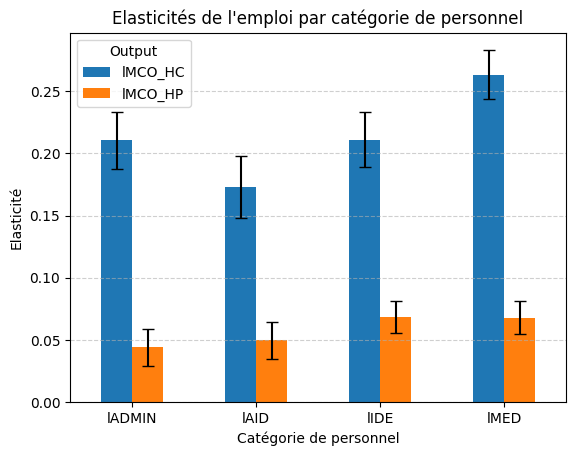

In [81]:
coef = table_elasticites.pivot(index="Personnel",columns="Output",values="Coefficient")
se = table_elasticites.pivot(index="Personnel",columns="Output",values="Std_Error")

ax = coef.plot(
    kind="bar",
    yerr=se,
    capsize=4
)

plt.title("Elasticités de l'emploi par catégorie de personnel")
plt.ylabel("Elasticité")
plt.xlabel("Catégorie de personnel")
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

On remarque notamment que les elasticités pour la médecine ambulatoire (MCO_HP) sont plus faibles que pour la médecine avec hospitalisation complète (MCO_HC), on comprend donc que des gains d'efficacité puisse être réalisés en développant la médecine ambulatoire

In [82]:
rows = []

for p in inputs:
    res = result_instr[p]
    
    for s in controles_statut:
        rows.append({
            "Personnel": p,
            "Statut": s,
            "Coefficient": res.params[s],
            "Std_Error": res.std_errors[s],
            "p_value": res.pvalues[s]
        })

table_statuts = pd.DataFrame(rows)


In [83]:
table_statuts

,Personnel,Statut,Coefficient,Std_Error,p_value
0,lMED,Statut_PNL,0.044873,0.077470,5.624335e-01
1,lMED,Statut_PL,0.118217,0.077955,1.293999e-01
2,lMED,Statut_CHU,0.528910,0.182268,3.709971e-03
3,lIDE,Statut_PNL,-0.118505,0.087233,1.743097e-01
4,lIDE,Statut_PL,-0.167436,0.084711,4.809090e-02
5,lIDE,Statut_CHU,1.036943,0.198490,1.749475e-07
6,lAID,Statut_PNL,-0.618350,0.088507,2.819744e-12
7,lAID,Statut_PL,-0.619032,0.083054,9.103829e-14
8,lAID,Statut_CHU,0.562663,0.273689,3.979723e-02
9,lADMIN,Statut_PNL,0.166697,0.085046,4.998559e-02


### 7 - Statistiques descriptives et graphiques

Etude des ratios de personnel médical par médecins :

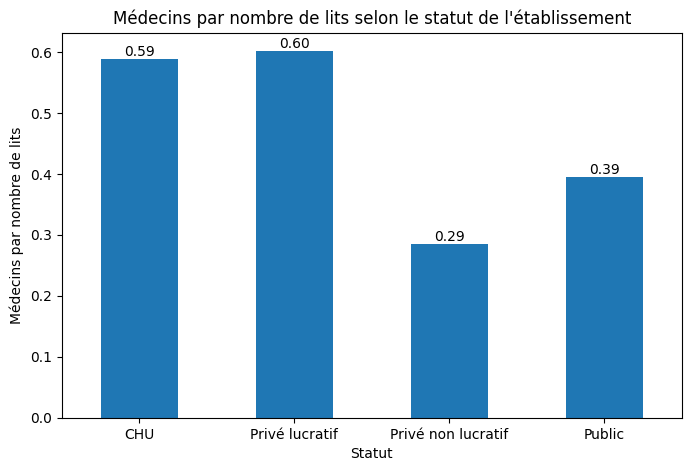

In [89]:
Data['lits'] = SYGEN2022['LIT_MCO'].fillna(0) + SYGEN2022['PLA_MED'].fillna(0) + SYGEN2022['LIT_SSR'].fillna(0) + SYGEN2022['LIT_USLD'].fillna(0)
Data_lits = Data[Data['lits'] > 0].copy()
Data_lits['ratio_med'] = Data_lits['EFF_MED'] / Data_lits['lits']
ax = Data_lits['ratio_med'].groupby(Data_lits["Statut"]).mean().plot(kind="bar", figsize=(8,5))
# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Médecins par nombre de lits")
plt.title("Médecins par nombre de lits selon le statut de l'établissement")
plt.xticks(rotation=0)
plt.show()

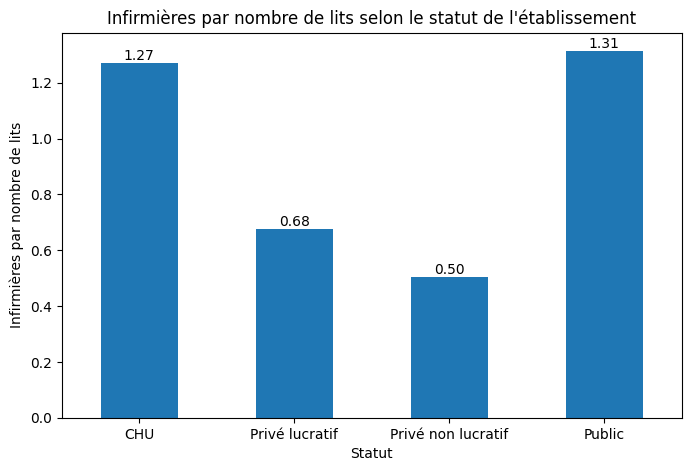

In [90]:
Data_lits['ratio_ide'] = Data_lits['EFF_IDE'] / Data_lits['lits']
ax = Data_lits['ratio_ide'].groupby(Data_lits["Statut"]).mean().plot(kind="bar", figsize=(8,5))
# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Infirmières par nombre de lits")
plt.title("Infirmières par nombre de lits selon le statut de l'établissement")
plt.xticks(rotation=0)
plt.show()

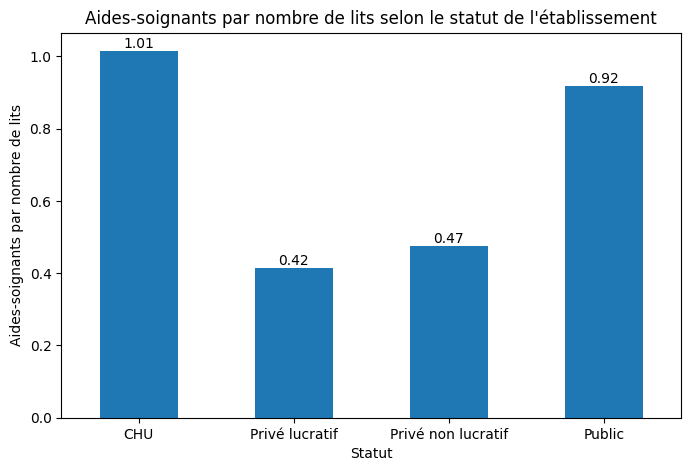

In [91]:
Data_lits['ratio_aid'] = Data_lits['EFF_AID'] / Data_lits['lits']
ax = Data_lits['ratio_aid'].groupby(Data_lits["Statut"]).mean().plot(kind="bar", figsize=(8,5))
# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Aides-soignants par nombre de lits")
plt.title("Aides-soignants par nombre de lits selon le statut de l'établissement")
plt.xticks(rotation=0)
plt.show()

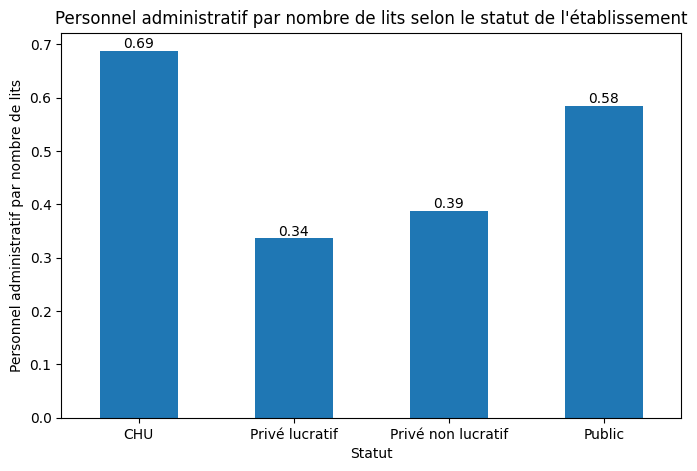

In [92]:
Data_lits['ratio_admin'] = Data_lits['EFF_ADMIN'] / Data_lits['lits']
ax = Data_lits['ratio_admin'].groupby(Data_lits["Statut"]).mean().plot(kind="bar", figsize=(8,5))
# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Personnel administratif par nombre de lits")
plt.title("Personnel administratif par nombre de lits selon le statut de l'établissement")
plt.xticks(rotation=0)
plt.show()

C:\Users\Alexandre\AppData\Local\Temp\ipykernel_21076\3381737263.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_med['ratio_IDE'] = Data_med['EFF_IDE'] / Data_med['EFF_MED']


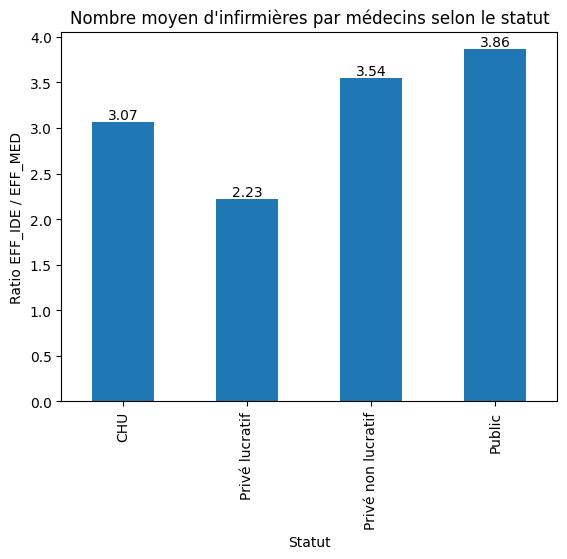

In [80]:
Data_med = Data[Data['EFF_MED'] > 0]
Data_med['ratio_IDE'] = Data_med['EFF_IDE'] / Data_med['EFF_MED']
ax = Data_med['ratio_IDE'].groupby(Data_med["Statut"]).mean().plot(kind="bar")

# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Ratio EFF_IDE / EFF_MED")
plt.title("Nombre moyen d'infirmières par médecins selon le statut")
plt.show()

C:\Users\Alexandre\AppData\Local\Temp\ipykernel_21076\2943411358.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_med['ratio_AID'] = Data_med['EFF_AID'] / Data_med['EFF_MED']


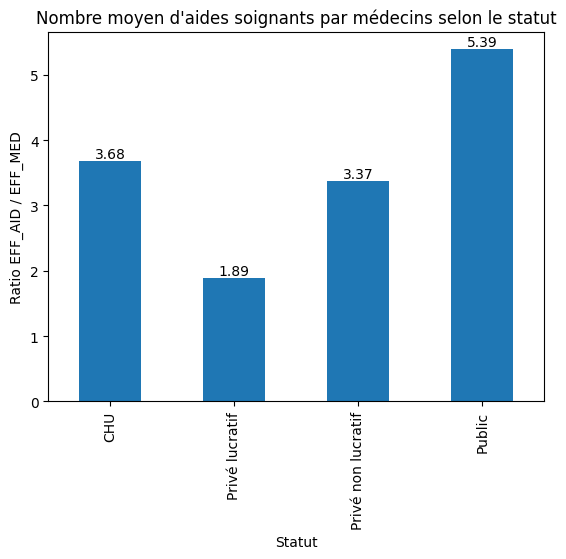

In [81]:
Data_med['ratio_AID'] = Data_med['EFF_AID'] / Data_med['EFF_MED']
ax = Data_med['ratio_AID'].groupby(Data_med["Statut"]).mean().plot(kind="bar")

# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Ratio EFF_AID / EFF_MED")
plt.title("Nombre moyen d'aides soignants par médecins selon le statut")
plt.show()

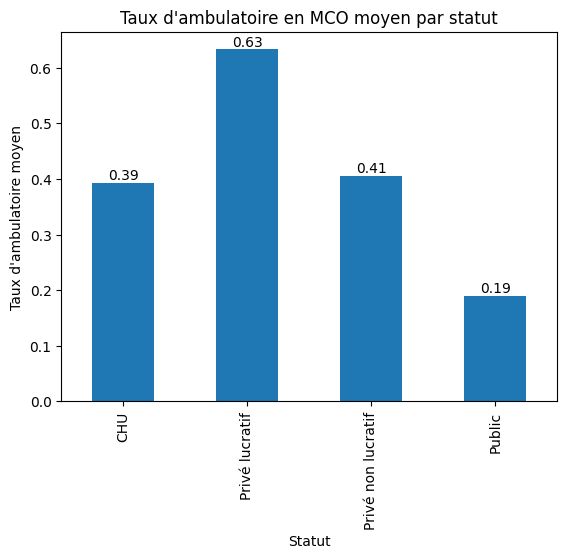

In [82]:
Data['taux_ambulatoire'] = Data['SEJHP_MCO'] / (Data['SEJHC_MCO'] + Data['SEJHP_MCO'])
ax = Data['taux_ambulatoire'].groupby(Data["Statut"]).mean().plot(kind="bar")

# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Taux d'ambulatoire moyen")
plt.title("Taux d'ambulatoire en MCO moyen par statut")
plt.show()

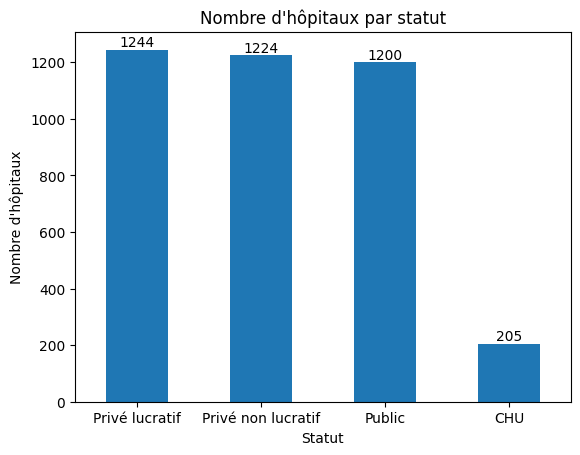

In [83]:
# Comptage des hôpitaux par statut
counts = Data["Statut"].value_counts()

# Graphique
ax = counts.plot(kind="bar")

# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylabel("Nombre d'hôpitaux")
plt.title("Nombre d'hôpitaux par statut")
plt.xticks(rotation=0)
plt.show()

In [98]:
vars_ratio = ["ratio_med","ratio_ide","ratio_aid","ratio_admin"]

table = Data_lits.groupby("Statut")[vars_ratio].mean().round(3)

In [99]:
table

,ratio_med,ratio_ide,ratio_aid,ratio_admin
Statut,,,,
CHU,0.588,1.269,1.015,0.687
Privé lucratif,0.602,0.677,0.415,0.336
Privé non lucratif,0.286,0.504,0.475,0.387
Public,0.395,1.313,0.918,0.584
